In [1]:
import os
import numpy as np
import pandas as pd
import glob
import shutil

import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
import matplotlib.pyplot as plt

In [42]:
import argparse

In [43]:
parser = argparse.ArgumentParser()

# Hardware
parser.add_argument("--device", default="gpu", help="Device to run the code")
parser.add_argument("--device_id", type=int, default=0, help="")

_StoreAction(option_strings=['--device_id'], dest='device_id', nargs=None, const=None, default=0, type=<class 'int'>, choices=None, help='', metavar=None)

In [2]:
base_dir = "D:/Sem 2/Data Analytics and Visualisation/Assignmnet 2/kvasir-dataset-v2/kvasir-dataset-v2"

In [3]:
os.listdir(base_dir)

['dyed-lifted-polyps',
 'dyed-resection-margins',
 'esophagitis',
 'normal-cecum',
 'normal-pylorus',
 'normal-z-line',
 'polyps',
 'ulcerative-colitis']

In [4]:
classes = ['dyed-lifted-polyps',
           'dyed-resection-margins',
           'esophagitis','normal-cecum',
           'normal-pylorus','normal-z-line',
           'polyps',
           'ulcerative-colitis']

In [5]:
#The dataset is split into train and test in such a way that 80% of the data as a training set 
#and 20% of the data as a test set
import os
import numpy as np
import shutil
import random
from numpy.random import seed
seed(553)

val_ratio = 0.15
test_ratio = 0.15

for cl in classes:
    
    img_path = os.path.join(base_dir, cl)
    images = glob.glob(img_path + '/*.jpg')
    #print("{}: {} Images".format(cl, len(images)))
    
    
    train_list, test_list, val_list = images[:round(len(images)*0.7)], images[round(len(images)*0.7):round(len(images)*0.85)], images[round(len(images)*0.85):]

    for image in train_list:
        if not os.path.exists(os.path.join(base_dir, 'train', cl)):
            os.makedirs(os.path.join(base_dir, 'train', cl))
        shutil.copy(image, os.path.join(base_dir, 'train', cl))

    for image in test_list:
        if not os.path.exists(os.path.join(base_dir, 'test', cl)):
            os.makedirs(os.path.join(base_dir, 'test', cl))
        shutil.copy(image, os.path.join(base_dir, 'test', cl))
    
    for image in val_list:
        if not os.path.exists(os.path.join(base_dir, 'val', cl)):
            os.makedirs(os.path.join(base_dir, 'val', cl))
        shutil.copy(image, os.path.join(base_dir, 'val', cl))

In [6]:
#IMAGE_SIZE = [224,224]

train_path = "D:/Sem 2/Data Analytics and Visualisation/Assignmnet 2/kvasir-dataset-v2/kvasir-dataset-v2/train"
Validation_path = "D:/Sem 2/Data Analytics and Visualisation/Assignmnet 2/kvasir-dataset-v2/kvasir-dataset-v2/val"

In [7]:
train_dataAugmentation = ImageDataGenerator(
      rescale=1./255
    )

test_dataAugmentation = ImageDataGenerator(rescale=1./255)

train_data_generator=train_dataAugmentation.flow_from_directory(train_path,
                                                 target_size=(200,200),
                                                 color_mode='rgb',
                                                 batch_size=32,
                                                 class_mode='categorical',
                                                 shuffle=True)

test_data_generator =test_dataAugmentation.flow_from_directory(Validation_path,
                                        target_size=(200,200),
                                       batch_size=50,
                                       class_mode='categorical')

Found 5600 images belonging to 8 classes.
Found 1200 images belonging to 8 classes.


In [8]:
train_data_generator.class_indices

{'dyed-lifted-polyps': 0,
 'dyed-resection-margins': 1,
 'esophagitis': 2,
 'normal-cecum': 3,
 'normal-pylorus': 4,
 'normal-z-line': 5,
 'polyps': 6,
 'ulcerative-colitis': 7}

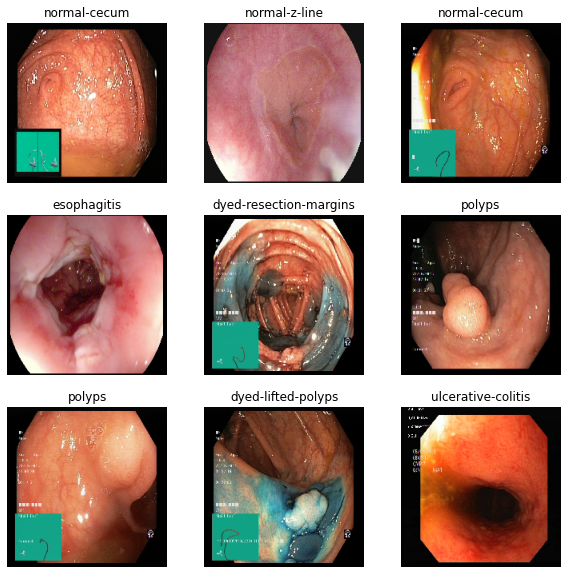

In [9]:
class_indices ={0:"dyed-lifted-polyps",1:"dyed-resection-margins",2:"esophagitis",3:"normal-cecum",4:"normal-pylorus",5:"normal-z-line",6:"polyps",7:"ulcerative-colitis"}

plt.figure(figsize=(10, 10))
for X_batch, y_batch in train_data_generator:
  for i in range(9):
    image=X_batch[i]
    ax = plt.subplot(3,3, i + 1)
    plt.imshow(image)
    plt.title(class_indices[list(y_batch[i]).index(1.0)])
    plt.axis("off")
  break

#### Baseline model 

In [10]:
model=Sequential()
################################### FEATURE EXTRACTOR 
model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512,activation='relu'))
model.add(Dense(8,activation='softmax'))

model.compile(loss='categorical_crossentropy',
  optimizer='adam',metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 100, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 100, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 50, 50, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 160000)            0         
                                                                 
 dropout (Dropout)           (None, 160000)            0

In [15]:
history = model.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),
                               generator=train_data_generator,
                               validation_data=test_data_generator,
                               validation_steps=test_data_generator.n//test_data_generator.batch_size,
                               epochs=30,
                               callbacks = ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)
)

<ipython-input-15-9ee51621666e>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),


Epoch 1/30
175/175 [==============================] - 284s 2s/step - loss: 1.3503 - accuracy: 0.5254 - val_loss: 0.9173 - val_accuracy: 0.5500
Epoch 2/30
175/175 [==============================] - 278s 2s/step - loss: 0.7784 - accuracy: 0.6346 - val_loss: 0.6676 - val_accuracy: 0.6967
Epoch 3/30
175/175 [==============================] - 285s 2s/step - loss: 0.7263 - accuracy: 0.6670 - val_loss: 0.6825 - val_accuracy: 0.6783
Epoch 4/30
175/175 [==============================] - 294s 2s/step - loss: 0.6736 - accuracy: 0.6914 - val_loss: 0.5868 - val_accuracy: 0.7392
Epoch 5/30
175/175 [==============================] - 302s 2s/step - loss: 0.6014 - accuracy: 0.7307 - val_loss: 0.5815 - val_accuracy: 0.7442
Epoch 6/30
175/175 [==============================] - 297s 2s/step - loss: 0.4876 - accuracy: 0.7884 - val_loss: 0.5919 - val_accuracy: 0.7483
Epoch 7/30
175/175 [==============================] - 306s 2s/step - loss: 0.3967 - accuracy: 0.8309 - val_loss: 0.7149 - val_accuracy: 0.7083

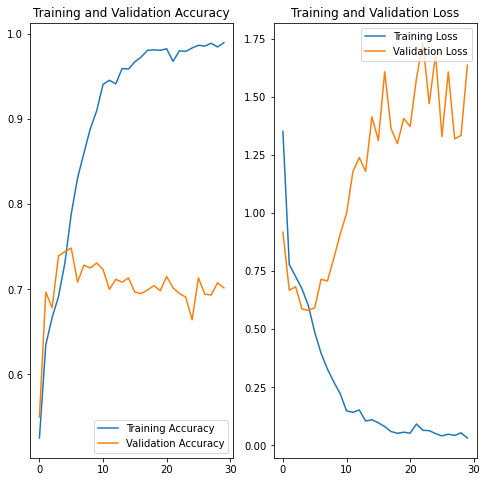

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [17]:
best_model = load_model(filepath='best_model.h5')
loss,acc=best_model.evaluate_generator(generator=test_data_generator,
steps=test_data_generator.n//test_data_generator.batch_size)

<ipython-input-17-ac98d57aee7c>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  loss,acc=best_model.evaluate_generator(generator=test_data_generator,


In [18]:
print ('The best model Loss : ',loss)
print ('The best model Accuracy : ',acc)

The best model Loss :  0.5815345644950867
The best model Accuracy :  0.7441666722297668


Github model

In [19]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(256,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512,activation='relu'))
model.add(Dense(8,activation='softmax'))

model.compile(loss='categorical_crossentropy',
  optimizer='adam',metrics=['accuracy'])

In [20]:
history = model.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),
                               generator=train_data_generator,
                               validation_data=test_data_generator,
                               validation_steps=test_data_generator.n//test_data_generator.batch_size,
                               epochs=100,
                               callbacks = [EarlyStopping(monitor='val_loss', patience=10),
                               ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)]
)

<ipython-input-20-ef3d62777726>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),


Epoch 1/100
175/175 [==============================] - 232s 1s/step - loss: 1.0672 - accuracy: 0.5984 - val_loss: 8.7575 - val_accuracy: 0.1250
Epoch 2/100
175/175 [==============================] - 230s 1s/step - loss: 0.6996 - accuracy: 0.6875 - val_loss: 2.5449 - val_accuracy: 0.2883
Epoch 3/100
175/175 [==============================] - 231s 1s/step - loss: 0.6372 - accuracy: 0.7200 - val_loss: 0.7309 - val_accuracy: 0.6758
Epoch 4/100
175/175 [==============================] - 229s 1s/step - loss: 0.5608 - accuracy: 0.7530 - val_loss: 1.4141 - val_accuracy: 0.5600
Epoch 5/100
175/175 [==============================] - 231s 1s/step - loss: 0.5114 - accuracy: 0.7738 - val_loss: 0.4892 - val_accuracy: 0.7925
Epoch 6/100
175/175 [==============================] - 226s 1s/step - loss: 0.4715 - accuracy: 0.7980 - val_loss: 0.8166 - val_accuracy: 0.6675
Epoch 7/100
175/175 [==============================] - 245s 1s/step - loss: 0.4197 - accuracy: 0.8207 - val_loss: 0.5759 - val_accuracy:

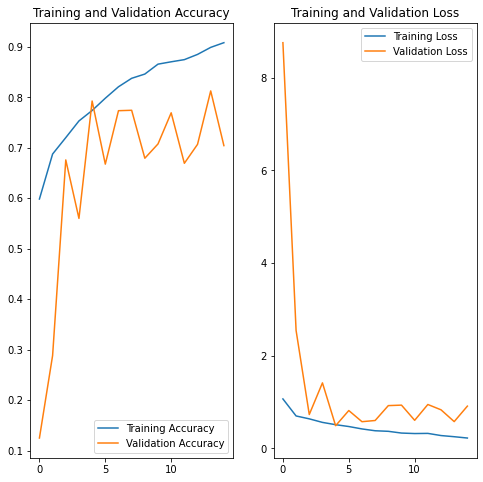

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [22]:
best_model = load_model(filepath='best_model.h5')
loss,acc=best_model.evaluate_generator(generator=test_data_generator,
steps=test_data_generator.n//test_data_generator.batch_size)

<ipython-input-22-ac98d57aee7c>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  loss,acc=best_model.evaluate_generator(generator=test_data_generator,


In [23]:
print ('The best model Loss : ',loss)
print ('The best model Accuracy : ',acc)

The best model Loss :  0.4892466366291046
The best model Accuracy :  0.7925000190734863


Our optimised model

In [24]:
model1=Sequential()
################################### FEATURE EXTRACTOR 
model1.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Conv2D(256,(3,3),padding='same',activation='relu'))
model1.add(BatchNormalization())
model1.add(MaxPooling2D(pool_size=(2,2)))

model1.add(Flatten())
model1.add(Dropout(0.5))
model1.add(Dense(1024,activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(512,activation='relu'))
model1.add(Dense(8,activation='softmax'))

model1.compile(loss='categorical_crossentropy',
  optimizer='adam',metrics=['accuracy'])

In [25]:
history1 = model1.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),
                               generator=train_data_generator,
                               validation_data=test_data_generator,
                               validation_steps=test_data_generator.n//test_data_generator.batch_size,
                               epochs=30,
                               callbacks = ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)
)

<ipython-input-25-6f9b013e8b87>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history1 = model1.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),


Epoch 1/30
175/175 [==============================] - 282s 2s/step - loss: 1.1082 - accuracy: 0.5545 - val_loss: 1.8843 - val_accuracy: 0.2708
Epoch 2/30
175/175 [==============================] - 308s 2s/step - loss: 0.7186 - accuracy: 0.6662 - val_loss: 1.1418 - val_accuracy: 0.5500
Epoch 3/30
175/175 [==============================] - 294s 2s/step - loss: 0.6561 - accuracy: 0.7011 - val_loss: 1.4847 - val_accuracy: 0.5092
Epoch 4/30
175/175 [==============================] - 286s 2s/step - loss: 0.6265 - accuracy: 0.7198 - val_loss: 1.3638 - val_accuracy: 0.5142
Epoch 5/30
175/175 [==============================] - 262s 1s/step - loss: 0.5717 - accuracy: 0.7404 - val_loss: 0.6155 - val_accuracy: 0.7133
Epoch 6/30
175/175 [==============================] - 257s 1s/step - loss: 0.5429 - accuracy: 0.7639 - val_loss: 0.8028 - val_accuracy: 0.6275
Epoch 7/30
175/175 [==============================] - 259s 1s/step - loss: 0.5318 - accuracy: 0.7620 - val_loss: 1.0935 - val_accuracy: 0.6383

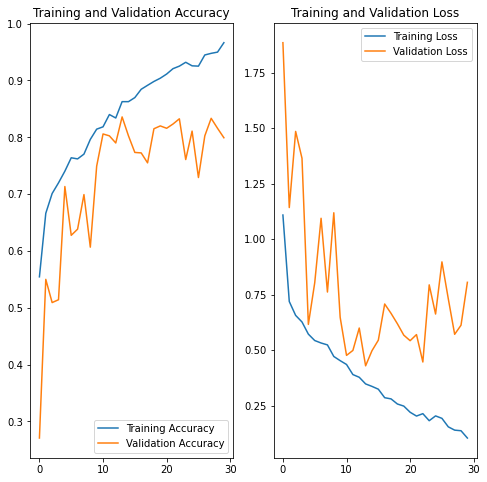

In [26]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [27]:
print ('The best model Loss : ',loss)
print ('The best model Accuracy : ',acc)

The best model Loss :  [1.1081655025482178, 0.7186081409454346, 0.6561079025268555, 0.626482367515564, 0.5716790556907654, 0.5428777933120728, 0.5317615270614624, 0.5231791734695435, 0.47107335925102234, 0.4522300064563751, 0.4350237250328064, 0.38958775997161865, 0.37737688422203064, 0.3474777340888977, 0.3363436460494995, 0.32369884848594666, 0.28538087010383606, 0.28002169728279114, 0.25699788331985474, 0.24765127897262573, 0.2198517918586731, 0.20266534388065338, 0.2135036140680313, 0.18173906207084656, 0.20343847572803497, 0.19236153364181519, 0.1541174352169037, 0.1392868310213089, 0.13660520315170288, 0.10372542589902878]
The best model Accuracy :  [0.5544642806053162, 0.6662499904632568, 0.7010714411735535, 0.7198214530944824, 0.7403571605682373, 0.7639285922050476, 0.7619642615318298, 0.7703571319580078, 0.7962499856948853, 0.8142856955528259, 0.8183928728103638, 0.8399999737739563, 0.8339285850524902, 0.862678587436676, 0.862678587436676, 0.8698214292526245, 0.884464263916015

cut-mix

In [28]:
AUTO = tf.data.AUTOTUNE
BATCH_SIZE = 64
EPOCHS = 10

In [30]:
pip install cutmix_keras

Note: you may need to restart the kernel to use updated packages.


In [31]:
from cutmix_keras import CutMixImageDataGenerator  # Import CutMix

In [32]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)

train_generator1 = train_datagen.flow_from_directory(
    train_path,
    target_size=(200, 200),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,  # Required
)

train_generator2 = train_datagen.flow_from_directory(
    train_path,
    target_size=(200, 200),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,  # Required
)

# !! Define CutMixImageDataGenerator !!
train_generator = CutMixImageDataGenerator(
    generator1=train_generator1,
    generator2=train_generator2,
    img_size= 200,
    batch_size=32,
)

Found 5600 images belonging to 8 classes.
Found 5600 images belonging to 8 classes.


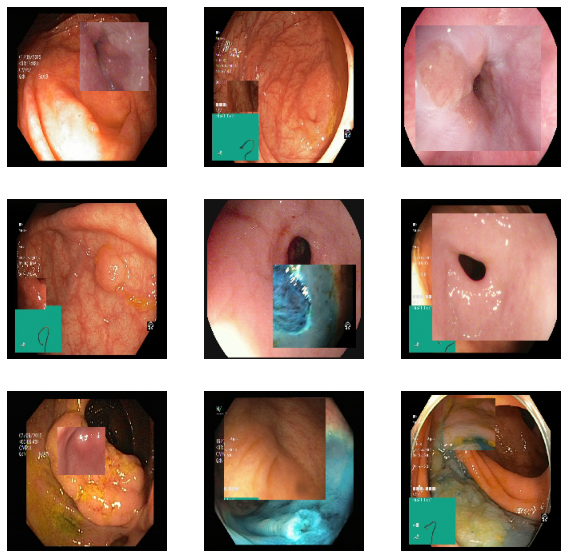

In [33]:
class_indices ={0:"dyed-lifted-polyps",1:"dyed-resection-margins",2:"esophagitis",3:"normal-cecum",4:"normal-pylorus",5:"normal-z-line",6:"polyps",7:"ulcerative-colitis"}

plt.figure(figsize=(10, 10))
for X_batch, y_batch in train_generator:
  for i in range(9):
    image=X_batch[i]
    ax = plt.subplot(3,3, i + 1)
    plt.imshow(image)
    #plt.title(class_indices[list(y_batch[i]).index(1.0)])
    plt.axis("off")
  break

In [34]:
# (some codes) ...
history = model1.fit_generator(steps_per_epoch=(train_generator.samples//train_generator.batch_size),
                               generator=train_generator,
                               validation_data=test_data_generator,
                               validation_steps=test_data_generator.n//test_data_generator.batch_size,
                               epochs=30,
                               callbacks = ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)
)

<ipython-input-34-5c4c9af0f8d4>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model1.fit_generator(steps_per_epoch=(train_generator.samples//train_generator.batch_size),


Epoch 1/30
175/175 [==============================] - 334s 2s/step - loss: 1.2686 - accuracy: 0.7143 - val_loss: 0.5298 - val_accuracy: 0.8308
Epoch 2/30
175/175 [==============================] - 326s 2s/step - loss: 1.0530 - accuracy: 0.7775 - val_loss: 0.5878 - val_accuracy: 0.7917
Epoch 3/30
175/175 [==============================] - 326s 2s/step - loss: 1.0040 - accuracy: 0.7859 - val_loss: 0.5281 - val_accuracy: 0.8158
Epoch 4/30
175/175 [==============================] - 328s 2s/step - loss: 0.9835 - accuracy: 0.7927 - val_loss: 0.5038 - val_accuracy: 0.8417
Epoch 5/30
175/175 [==============================] - 329s 2s/step - loss: 0.9648 - accuracy: 0.7945 - val_loss: 0.5564 - val_accuracy: 0.8133
Epoch 6/30
175/175 [==============================] - 309s 2s/step - loss: 0.9513 - accuracy: 0.7973 - val_loss: 0.5311 - val_accuracy: 0.7975
Epoch 7/30
175/175 [==============================] - 320s 2s/step - loss: 0.9160 - accuracy: 0.7989 - val_loss: 0.5109 - val_accuracy: 0.8183

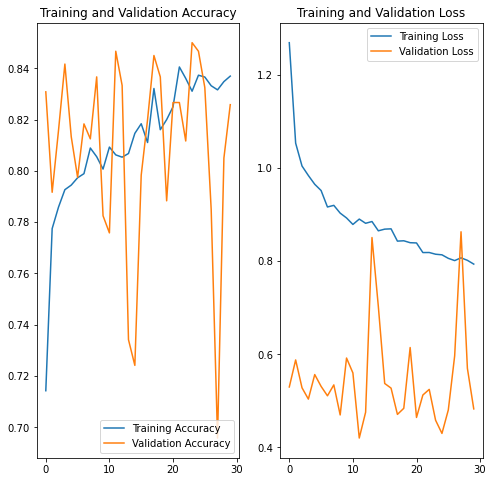

In [35]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [36]:
print ('The best model Loss : ',loss)
print ('The best model Accuracy : ',acc)

The best model Loss :  [1.268593192100525, 1.053015112876892, 1.00395667552948, 0.9835436940193176, 0.9647629857063293, 0.951349675655365, 0.9160338640213013, 0.919519305229187, 0.902857780456543, 0.8925022482872009, 0.878563642501831, 0.890064001083374, 0.8810482621192932, 0.8848272562026978, 0.8649179339408875, 0.868489146232605, 0.869154155254364, 0.8427870273590088, 0.8435136079788208, 0.8393848538398743, 0.838874876499176, 0.8182339072227478, 0.8183557987213135, 0.8146700859069824, 0.8133909106254578, 0.8058258295059204, 0.8010204434394836, 0.8069373369216919, 0.8015815019607544, 0.7934616804122925]
The best model Accuracy :  [0.7142857313156128, 0.7774999737739563, 0.7858928442001343, 0.7926785945892334, 0.7944642901420593, 0.7973214387893677, 0.7989285588264465, 0.8089285492897034, 0.8055357336997986, 0.8007143139839172, 0.8092857003211975, 0.8062499761581421, 0.8053571581840515, 0.8067857027053833, 0.8146428465843201, 0.8183928728103638, 0.8110714554786682, 0.8321428298950195, 

Question 2 - Random Forest

In [37]:
dir = "D:/Sem 2/Data Analytics and Visualisation/Assignmnet 2/kvasir-dataset-v2-features/kvasir-dataset-v2-features/"

In [38]:
os.listdir(dir)

['dyed-lifted-polyps',
 'dyed-resection-margins',
 'esophagitis',
 'normal-cecum',
 'normal-pylorus',
 'normal-z-line',
 'polyps',
 'ulcerative-colitis']

In [39]:
feature_class = ['dyed-lifted-polyps',
 'dyed-resection-margins',
 'esophagitis',
 'normal-cecum',
 'normal-pylorus',
 'normal-z-line',
 'polyps',
 'ulcerative-colitis']

In [40]:
feature_class.index('dyed-lifted-polyps')

0

In [41]:
list1 = []
for cl in feature_class:
    
    file_path =  os.path.join(dir, cl)
    #print(file_path)
    file = glob.glob(file_path + '/*.features')
    #print(file)
    
    for single_file in file:
        list2 = []
        f = open(single_file, "r")
        #print(f.read())
        a = f.read()

        a = a.strip().split()
        
        jcd = list(map(float, a[0].split(':')[1].split(',')))
        Tamura = list(map(float, a[1].split(':')[1].split(',')))
        ColorLayout = list(map(float, a[2].split(':')[1].split(',')))
        EdgeHistogram = list(map(float, a[3].split(':')[1].split(',')))
        AutoColorCorrelogram = list(map(float, a[4].split(':')[1].split(',')))
        PHOG = list(map(float, a[5].split(':')[1].split(',')))
        
        list2.extend(jcd)
        list2.extend(Tamura)
        list2.extend(ColorLayout)
        list2.extend(EdgeHistogram)
        list2.extend(AutoColorCorrelogram)
        list2.extend(PHOG)
        list2.append(feature_class.index(cl))
        
        list1.append(list2)
#print(list1)
    

In [42]:
len(list1[0])

1186

In [43]:
list1[0]

[0.5,
 2.0,
 4.5,
 0.0,
 0.0,
 0.0,
 3.5,
 3.5,
 5.0,
 0.0,
 0.0,
 0.0,
 0.5,
 0.0,
 0.0,
 1.0,
 2.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.5,
 0.5,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.5,
 0.5,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.5,
 1.0,
 1.5,
 0.0,
 0.0,
 0.0,
 2.0,
 2.0,
 3.5,
 0.0,
 0.0,
 0.5,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0

In [44]:
df = pd.DataFrame(list1)
df

,0,1,2,3,4,5,6,7,8,9,...,1176,1177,1178,1179,1180,1181,1182,1183,1184,1185
0,0.5,2.0,4.5,0.0,0.0,0.0,3.5,3.5,5.0,0.0,...,3.0,3.0,6.0,6.0,4.0,2.0,2.0,1.0,3.0,0
1,0.0,1.5,4.5,0.0,0.0,0.0,2.5,1.5,3.5,0.0,...,6.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,0
2,1.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,14.0,3.0,5.0,14.0,0.0,0.0,4.0,3.0,0.0,0
3,1.5,2.5,5.5,0.5,0.5,0.5,2.5,3.0,3.5,0.0,...,0.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0,6.0,0
4,3.0,3.5,6.0,0.0,0.0,0.0,1.0,0.0,0.5,0.5,...,4.0,1.0,3.0,3.0,1.0,2.0,14.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.5,0.0,5.0,0.0,0.5,0.0,3.5,4.5,3.5,0.0,...,6.0,9.0,10.0,10.0,15.0,10.0,8.0,9.0,13.0,7
7996,0.0,0.0,5.0,0.0,0.5,0.5,0.5,5.0,4.5,0.0,...,12.0,14.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0,7
7997,0.0,0.0,5.5,0.0,0.0,0.0,1.0,5.0,4.0,0.0,...,5.0,6.0,6.0,4.0,5.0,7.0,3.0,3.0,10.0,7
7998,2.0,0.0,5.5,0.0,0.0,1.0,1.0,5.0,5.0,0.0,...,7.0,15.0,12.0,5.0,1.0,0.0,0.0,0.0,3.0,7


In [45]:
df.loc[:,1185]

0       0
1       0
2       0
3       0
4       0
       ..
7995    7
7996    7
7997    7
7998    7
7999    7
Name: 1185, Length: 8000, dtype: int64

In [46]:
df.loc[:, df.columns != 1185]

,0,1,2,3,4,5,6,7,8,9,...,1175,1176,1177,1178,1179,1180,1181,1182,1183,1184
0,0.5,2.0,4.5,0.0,0.0,0.0,3.5,3.5,5.0,0.0,...,7.0,3.0,3.0,6.0,6.0,4.0,2.0,2.0,1.0,3.0
1,0.0,1.5,4.5,0.0,0.0,0.0,2.5,1.5,3.5,0.0,...,0.0,6.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0
2,1.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,14.0,3.0,5.0,14.0,0.0,0.0,4.0,3.0,0.0
3,1.5,2.5,5.5,0.5,0.5,0.5,2.5,3.0,3.5,0.0,...,0.0,0.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0,6.0
4,3.0,3.5,6.0,0.0,0.0,0.0,1.0,0.0,0.5,0.5,...,8.0,4.0,1.0,3.0,3.0,1.0,2.0,14.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.5,0.0,5.0,0.0,0.5,0.0,3.5,4.5,3.5,0.0,...,6.0,6.0,9.0,10.0,10.0,15.0,10.0,8.0,9.0,13.0
7996,0.0,0.0,5.0,0.0,0.5,0.5,0.5,5.0,4.5,0.0,...,10.0,12.0,14.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0
7997,0.0,0.0,5.5,0.0,0.0,0.0,1.0,5.0,4.0,0.0,...,6.0,5.0,6.0,6.0,4.0,5.0,7.0,3.0,3.0,10.0
7998,2.0,0.0,5.5,0.0,0.0,1.0,1.0,5.0,5.0,0.0,...,2.0,7.0,15.0,12.0,5.0,1.0,0.0,0.0,0.0,3.0


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
(train_X, test_X, train_y, test_y) = train_test_split(
    df.loc[:, df.columns != 1185], df.loc[:,1185], test_size=0.3, random_state=0)

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
model=RandomForestClassifier(n_estimators=100)

In [52]:
model.fit(train_X, train_y)

RandomForestClassifier()

In [53]:
y_pred=model.predict(test_X)
y_pred

array([3, 0, 3, ..., 4, 6, 2], dtype=int64)

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [55]:
accuracy_score(y_pred,test_y)
print(classification_report(y_pred,test_y))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       318
           1       0.67      0.70      0.69       271
           2       0.67      0.75      0.70       273
           3       0.94      0.83      0.88       339
           4       0.95      0.93      0.94       311
           5       0.79      0.70      0.74       335
           6       0.66      0.74      0.70       273
           7       0.73      0.78      0.76       280

    accuracy                           0.77      2400
   macro avg       0.77      0.76      0.76      2400
weighted avg       0.77      0.77      0.77      2400



In [56]:
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
CV_rfc = GridSearchCV(estimator=model, param_grid=param_grid, cv= 5)
CV_rfc.fit(train_X, train_y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 500]})

In [59]:
CV_rfc.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'max_features': 'sqrt',
 'n_estimators': 500}

In [60]:
rfc1=RandomForestClassifier(random_state=42, max_features='auto', n_estimators= 200, max_depth=8, criterion='gini')

In [61]:
model.fit(train_X, train_y)

RandomForestClassifier()

In [62]:
y_pred=model.predict(test_X)
y_pred

array([3, 0, 3, ..., 4, 6, 2], dtype=int64)

In [65]:
print("Accuracy for Random Forest on CV data: ",accuracy_score(y_pred,test_y))

Accuracy for Random Forest on CV data:  0.7804166666666666


In [67]:
#op_rf=rfc1.predict(test_df)